### Cell 1 — Setup & config

In [1]:
import numpy as np, torch, torch.nn as nn
from utils import load_dataset, run_cv_bio_vs_biotopo, delong_roc_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng_seed = 13

# Load per-view datasets
Xb_tr, y_tr, Xb_te, y_te, b_cols = load_dataset("../datasets/BioFeats")
Xt_tr, yt_tr, Xt_te, yt_te, t_cols = load_dataset("../datasets/TopoFeats_BioEmb")
assert np.all(y_tr==yt_tr) and np.all(y_te==yt_te)

In [2]:
train_cfg = dict(hidden=(256,128), pdrop=0.1, epochs=20, batch_size=256,
                 lr=1e-3, weight_decay=1e-4, patience=5, min_delta=5e-4, seed=13)

out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, mode="sym4",
                            n_splits=5, n_repeats=5,
                            undersample=True, train_cfg=train_cfg, base_seed=13)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")

{'AUC_mean': 0.9343138664677433, 'AUC_std': 0.0016997512171028364, 'AP_mean': 0.9993810727165263, 'AP_std': 2.183159280101789e-05, 'F1_mean': 0.9187368876969959, 'F1_std': 0.002583211607175795, 'ACC_mean': 0.8508402087546871, 'ACC_std': 0.004341699066200287, 'PREC_mean': 0.9989009813655698, 'PREC_std': 8.13779318477895e-05, 'REC_mean': 0.850635685203421, 'REC_std': 0.0043994621988799505}
{'AUC_mean': 0.9408718700422728, 'AUC_std': 0.0015861620283103943, 'AP_mean': 0.9994579060420982, 'AP_std': 2.4444279095297442e-05, 'F1_mean': 0.9193458365543228, 'F1_std': 0.004227442926159031, 'ACC_mean': 0.8519628195996566, 'ACC_std': 0.007042121652124865, 'PREC_mean': 0.9990345101166467, 'PREC_std': 7.220821195137766e-05, 'REC_mean': 0.8516543197694961, 'REC_std': 0.007159792076427478}
AUC(bio)=0.9334  AUC(bio+topo)=0.9394  Δ=0.0060  p=0.705


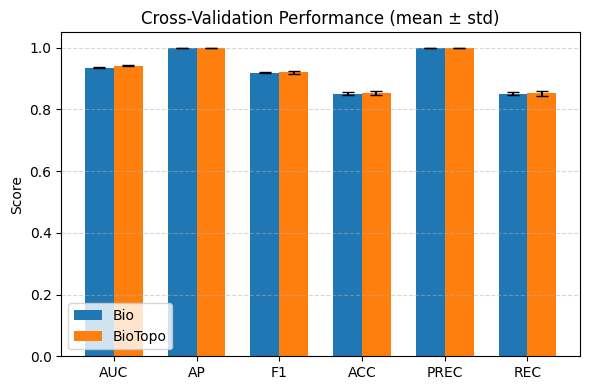

In [4]:
from utils import plot_metric_bars
import matplotlib.pyplot as plt

# out is the result from run_cv_bio_vs_biotopo(...)
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   # keys inside your summary dict
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"), 
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()